<a href="https://colab.research.google.com/github/DesmondLo/AIVC-/blob/main/%E6%96%B0%E7%94%9F%E7%AC%AC%E4%BA%8C%E9%80%B1%E4%BD%9C%E6%A5%AD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 說明



1.   請使用Numpy完成程式碼，禁止額外套用套件，可以使用cv2_imread
2.   可以使用自己完成的副程式
3.   完成程式碼後，請與cv2的結果做對比
4.   輸出圖片與cv2的結果需要一致



# 引入套件

In [ ]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow

圖片來源 https://upload.wikimedia.org/wikipedia/zh/3/34/Lenna.jpg

# 顯示原圖片

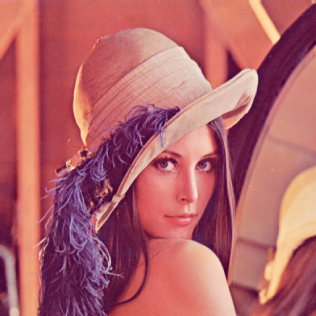

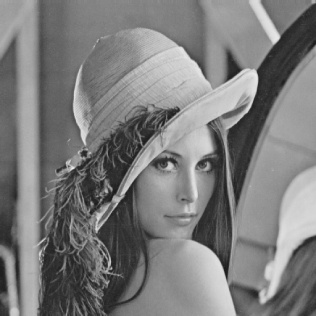

In [ ]:
# Opencv結果
img = cv2.imread('lena.jpg') # 讀取圖片
img_g = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # 彩色轉灰階
cv2_imshow(img) # 顯示圖片
cv2_imshow(img_g)

# 二值化 binarize

## 說明

二值化是將圖像轉換成只有兩種像素值的過程，通常是黑色(0)和白色（255）。這通常是通過設置一個閾值來實現的，高於閾值的像素設置為一個值，低於閾值的像素設置為另一個值。

二值化常用於從圖像中分離出前景和背景，尤其是在文字識別、條形碼識別和其他需要分辨物體輪廓的應用中。

[連結文字](https://www.google.com/url?sa=i&url=https%3A%2F%2Fhackmd.io%2F%40Youwe%2FSkBHZmcrI&psig=AOvVaw0gepMQc5qRlv9XhV0K7Ojg&ust=1706693413559000&source=images&cd=vfe&opi=89978449&ved=0CBIQjRxqFwoTCKjI_8bmhIQDFQAAAAAdAAAAABAE)

## 代碼

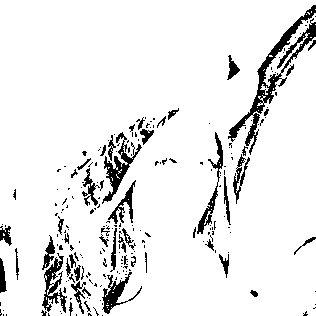

In [ ]:
# Opencv結果
rer, img_b = cv2.threshold(img_g, 50, 255, cv2.THRESH_BINARY)
cv2_imshow(img_b)

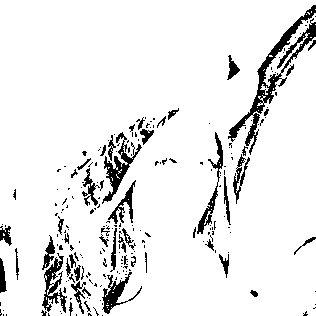

二值化結果 True


In [ ]:
def binarize(img,thresh,maxval):
  # TODO 待完成程式碼，只允許使用numpy或是自己寫的副程式
  return out # 回傳圖片

result = binarize(img_g, 50, 255)
cv2_imshow(result)
print("二值化結果", np.array_equal(result, img_b))

# 大津演算法 OTSU

## 說明

在大津演算法中，我們的目標是找到一個最適合的閾值，以便將影像的像素分成前景和背景兩個類別。

以下是大津演算法中用來計算類間變異數的公式及一些名詞解釋。

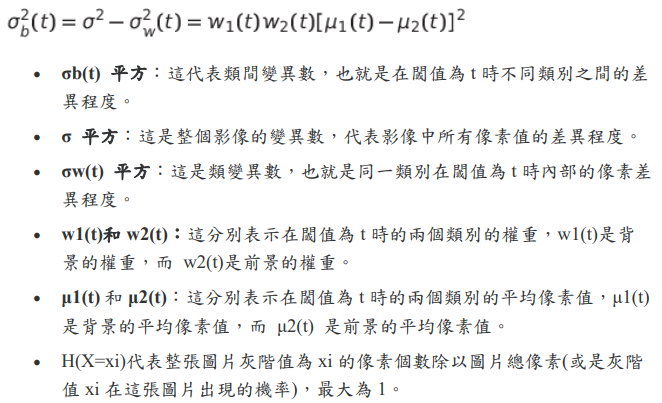

演算法的步驟如下：
1. 計算每個灰階值的直方圖並計算出現的 PMF 機率質量函數 H(X=xi)。
2. 初始化變數 w1(0) 和 μ1(0)。
3. 遍歷閾值 t 從 0 到 255 的範圍：
  1. 計算參數 w1(t)、μ1(t)、w2(t)、μ2(t)。
  2. 計算類間變異數 σb(t)。
  3. 如果目前的類間變異數大於先前的最大值，更新最大值。
  4. 記錄當前的閾值 t。
4. 最終，使用記錄的閾值找到最大類間變異數對應的閾值。


大津演算法在二值化影像、圖像分割等領域有廣泛應用，因為它能夠自動選擇
適當的閾值，而不需要人為調整。

## 代碼

117.0


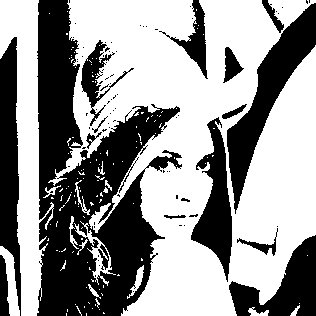

In [ ]:
# Opencv結果
ret, img_o = cv2.threshold(img_g, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(ret)
cv2_imshow(img_o)

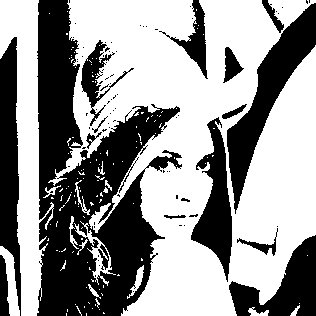

otsu結果 True


In [ ]:
def otsu(img_gray):
  # TODO 待完成程式碼，只允許使用numpy或是自己寫的副程式
  return th # 回傳閾值

ret = otsu(img_g) # 使用設計的otsu副程式，得到閾值
result = binarize(img_g, ret, 255) # 使用剛剛完成的二值化副程式

cv2_imshow(result)
print("otsu結果", np.array_equal(result, img_o))

# 腐蝕 Erode

## 說明

腐蝕是一種侵蝕圖像前景的操作，它會移除圖像邊緣的像素。這是通過將一個結構元素滑動過圖像，並只保留結構元素完全覆蓋前景的區域來實現的。

腐蝕用於去除小的噪點，分離相鄰的物體，並縮小物體的大小。這在處理不規則形狀或消除小於某個大小的物體時非常有用。

[連結文字](https://www.google.com/url?sa=i&url=https%3A%2F%2Fshengyu7697.github.io%2Fpython-opencv-erode-dilate%2F&psig=AOvVaw29YmyilbAS0RFCKQpbipo8&ust=1706693534273000&source=images&cd=vfe&opi=89978449&ved=0CBIQjRxqFwoTCIjluoDnhIQDFQAAAAAdAAAAABAE)

## 代碼

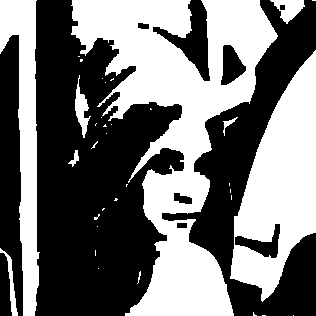

In [ ]:
# Opencv結果
kernel = np.ones((3,3))
img_e = cv2.erode(img_o, kernel, iterations = 2)
cv2_imshow(img_e)

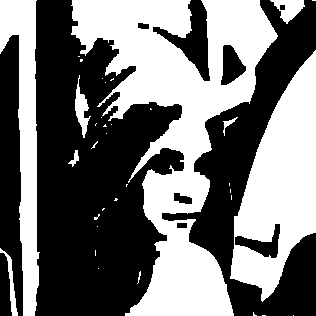

腐蝕結果 True


In [ ]:
def erode(img,kernel,iterations=1):
  # TODO 待完成程式碼，只允許使用numpy或是自己寫的副程式
  return out # 輸出圖片

result = erode(img_o, kernel, iterations = 2) # 使用設計的腐蝕副程式，得到腐蝕後的圖片
cv2_imshow(result)
print("腐蝕結果", np.array_equal(result, img_e))

# 膨脹 Dilate

## 說明

膨脹是與腐蝕相反的操作，它會增加圖像前景的像素。這是通過將一個結構元素滑動過圖像，並將結構元素接觸到的所有背景轉換為前景來實現的。

膨脹用於填充前景物體中的小洞，連接靠近的物體，並增加物體的大小。這在強調特定特徵或閉合小的間隙時很有幫助。

## 代碼

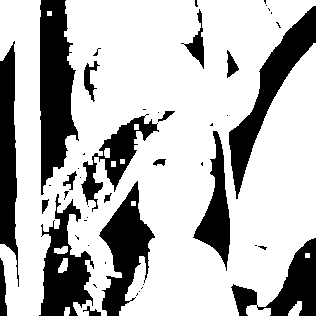

In [ ]:
# Opencv結果
kernel = np.ones((3,3))
img_d = cv2.dilate(img_o, kernel, iterations = 2)
cv2_imshow(img_d)

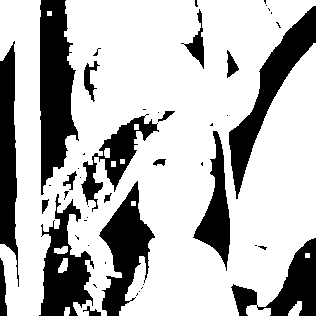

膨脹結果 True


In [ ]:
def dilate(img,kernel,iterations=1):
  # TODO 待完成程式碼，只允許使用numpy或是自己寫的副程式
  return out # 輸出圖片

result = dilate(img_o, kernel, iterations = 2) # 使用設計的膨脹副程式，得到膨脹後的圖片
cv2_imshow(result)
print("膨脹結果", np.array_equal(result, img_d))

# 開運算 Open

## 說明

開運算是由一個腐蝕（Erosion）操作後接著一個膨脹（Dilation）操作組成的序列。

開運算可以用來去除二值化影像中的小物體，填充物體內的小洞。

開運算的效果是平滑物體邊界，同時保持物體的整體形狀。

## 代碼

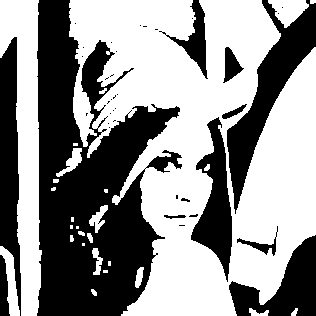

In [ ]:
# Opencv結果
kernel = np.ones((3,3))
img_open = cv2.morphologyEx(img_o, cv2.MORPH_OPEN, kernel)
cv2_imshow(img_open)

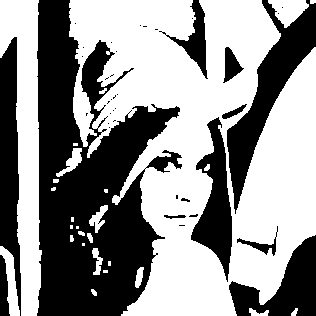

開運算結果 True


In [ ]:
def open(img, kernel):
  # TODO 待完成程式碼，只允許使用numpy或是自己寫的副程式
  return out # 輸出圖片

result = open(img_o, kernel) # 使用設計的開運算副程式，得到開運算後的圖片
cv2_imshow(result)
print("開運算結果", np.array_equal(result, img_open))

# 閉運算 Close

## 說明

閉運算是由一個膨脹（Dilation）操作後接著一個腐蝕（Erosion）操作組成的序列。

閉運算可以用來填充二值化影像中的小孔，平滑物體內部的細小細節。

閉運算的效果是平滑物體的表面，同時保持物體的整體形狀。


## 代碼

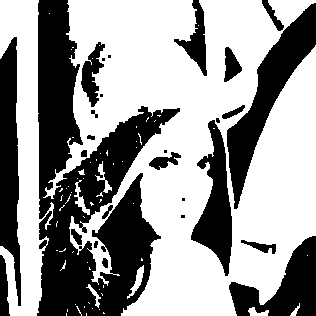

In [ ]:
# Opencv結果
kernel = np.ones((3,3))
img_close = cv2.morphologyEx(img_o, cv2.MORPH_CLOSE, kernel)
cv2_imshow(img_close)

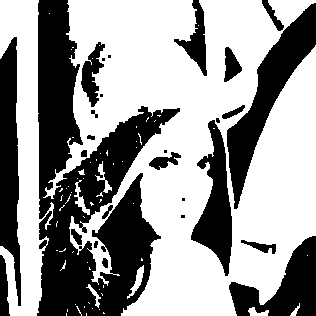

閉運算結果 True


In [ ]:
def close(img, kernel):
  # TODO 待完成程式碼，只允許使用numpy或是自己寫的副程式
  return out # 輸出圖片

result = close(img_o, kernel) # 使用設計的閉運算副程式，得到閉運算後的圖片
cv2_imshow(result)
print("閉運算結果", np.array_equal(result, img_close))

# 所有輸出都為True後，請上傳到群組中
